# Title

## Module Imports

In [1]:
import pickle
import mlflow
import matplotlib.pyplot as plt
from experiment import load_config, CelltypeResult, SampleResult

/Users/egerc/Documents/Projects/notebook_repository/notebooks/2026-02-17T08-24-52Z/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Environment Variables

In [2]:
config = load_config()

In [3]:
benchmark_experiment = mlflow.get_experiment_by_name(config.mlflow_experiment_name)
runs = mlflow.search_runs(
    experiment_ids=[benchmark_experiment.experiment_id], output_format="list"
)
parent_runs = [
    run for run in runs if run.data.tags["mlflow.runName"] == "dataset_predictor_sweep"
]
parent_run_id = parent_runs[0].info.run_id
daughter_runs = [
    run for run in runs if run.data.tags.get("mlflow.parentRunId") == parent_run_id
]

2026/02/18 16:52:09 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/18 16:52:09 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/18 16:52:09 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/18 16:52:09 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/18 16:52:09 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/18 16:52:09 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/18 16:52:09 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/18 16:52:09 INFO alembic.runtime.migration: Will assume non-transactional DDL.


In [4]:
run = daughter_runs[1]
run_id = run.info.run_id
artifact_path = mlflow.artifacts.download_artifacts(
    run_id=run_id, artifact_path="results.pkl"
)
with open(artifact_path, "rb") as f:
    results = pickle.load(f)

In [5]:
run

<Run: data=<RunData: metrics={}, params={'dataset': 'small_mouse_intestine_spatial', 'predictor': 'NMF_3'}, tags={'mlflow.parentRunId': '055c718018a24b6b853ce12af76ddf4b',
 'mlflow.runName': 'NMF_3_small_mouse_intestine_spatial',
 'mlflow.source.git.commit': '68ba0ad4427507b7fb507d29ef5b8106b91a3a7c',
 'mlflow.source.name': 'experiment.py',
 'mlflow.source.type': 'LOCAL',
 'mlflow.user': 'egerc'}>, info=<RunInfo: artifact_uri='/Users/egerc/Documents/Projects/notebook_repository/notebooks/2026-02-17T08-24-52Z/mlruns/1/7c48c03ef2784494b092237b24cc555f/artifacts', end_time=1771429872770, experiment_id='1', lifecycle_stage='active', run_id='7c48c03ef2784494b092237b24cc555f', run_name='NMF_3_small_mouse_intestine_spatial', start_time=1771429863322, status='FINISHED', user_id='egerc'>, inputs=<RunInputs: dataset_inputs=[], model_inputs=[]>, outputs=<RunOutputs: model_outputs=[]>>

In [6]:
result = results[0]
result.__dataclass_fields__

{'celltype': Field(name='celltype',type='str',default=<dataclasses._MISSING_TYPE object at 0x103dc9550>,default_factory=<dataclasses._MISSING_TYPE object at 0x103dc9550>,init=True,repr=True,hash=None,compare=True,metadata=mappingproxy({}),kw_only=False,_field_type=_FIELD),
 'celltype_pca_embedding': Field(name='celltype_pca_embedding',type='NumericArray',default=<dataclasses._MISSING_TYPE object at 0x103dc9550>,default_factory=<dataclasses._MISSING_TYPE object at 0x103dc9550>,init=True,repr=True,hash=None,compare=True,metadata=mappingproxy({}),kw_only=False,_field_type=_FIELD),
 'celltype_umap_embedding': Field(name='celltype_umap_embedding',type='NumericArray',default=<dataclasses._MISSING_TYPE object at 0x103dc9550>,default_factory=<dataclasses._MISSING_TYPE object at 0x103dc9550>,init=True,repr=True,hash=None,compare=True,metadata=mappingproxy({}),kw_only=False,_field_type=_FIELD),
 'global_model': Field(name='global_model',type='n2l.pd.PredictorProtocol',default=<dataclasses._MISSI

In [7]:
from sklearn.cluster import KMeans

global_model_clustering = KMeans(
    n_clusters=result.global_model_embedding_size
).fit_predict(result.celltype_pca_embedding)
celltype_model_clustering = KMeans(
    n_clusters=result.celltype_model_embedding_size
).fit_predict(result.celltype_pca_embedding)

In [8]:
sample = result.samples[0]

Text(0.5, 1.0, 'BZE')

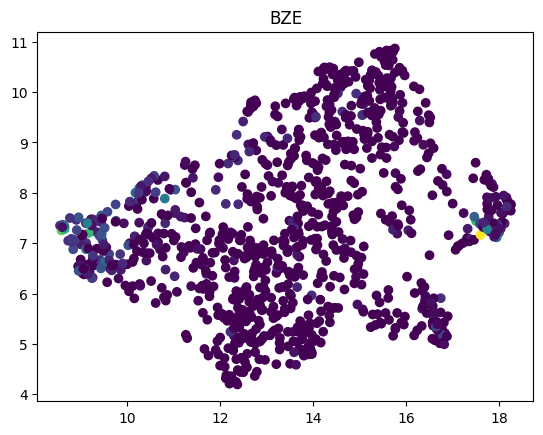

In [9]:
plt.scatter(*result.celltype_umap_embedding.T, c=sample.celltype_model_embeddings[:, 2])
plt.title(f"{result.celltype}")

## Data Generation

## Data Visualizations